# Análise de dados no dataset `titanic`

Repositório obtido a partir de: https://www.kaggle.com/datasets/yasserh/titanic-dataset.

> Description:
> The sinking of the Titanic is one of the most infamous shipwrecks in history.

> On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. > > Unfortunately, there weren’t enough lifeboats for everyone on board, resulting in the death of 1502 out of 2224 passengers and crew.

> While there was some element of luck involved in surviving, it seems some groups of people **were more likely to survive than others**.

>In this challenge, we ask you to build a predictive model that answers the question: **“what sorts of people were more likely to survive?”** using passenger data (ie name, age, gender, socio-economic class, etc).

----

## Bibliotecas básicas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import seaborn as sns

sns.set_style(style='whitegrid')

font_options = {
    'family': 'serif',
    'size': 14
}
plt.rc('font', **font_options)

## Importando o dataset e visualizando coisas essenciais

In [2]:
titanicdf = pd.read_csv('./Titanic-Dataset.csv')

In [3]:
titanicdf.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print(f"Número de linhas: {titanicdf.shape[0]} | Número de colunas: {titanicdf.shape[1]}.")

Número de linhas: 891 | Número de colunas: 12.


In [5]:
titanicdf.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
titanicdf.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

## Tratamentos das linhas e colunas

### Eliminando colunas não relevantes

* `id do passageiro` não é relevante, não nos traz informação adicional, pois é gerado automaticamente.
* `nome do passegeiro` não é relevante, não nos traz mais informação útil por sua especificidade.
* `ticket` também não nos ajudará a entender muito sobre o problema, visto que é um número gerado automaticamente. 

In [7]:
titanicdf.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [8]:
cols_to_drop = ['PassengerId', 'Name', 'Ticket']
titanicdf = titanicdf.drop(columns=cols_to_drop)

In [9]:
print("Novo número de colunas: ", titanicdf.shape[1])

Novo número de colunas:  9


### Tratando tipos de dados e valores das colunas

In [10]:
titanicdf.dtypes

Survived      int64
Pclass        int64
Sex             str
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin           str
Embarked        str
dtype: object

In [11]:
titanicdf.Survived.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: >

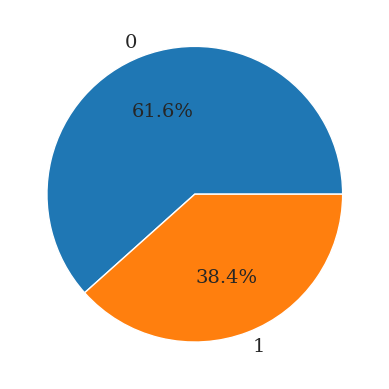

In [12]:
titanicdf.Survived.value_counts().plot.pie(autopct='%1.1f%%')

[Text(0, 0, '1ª classe'), Text(1, 0, '2ª classe'), Text(2, 0, '3ª classe')]

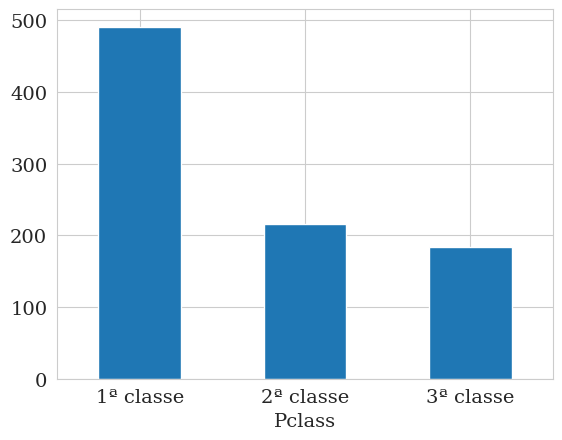

In [13]:
# manter ordinal visto que existe ordem natural dos valores ( 1ª classe > 2ª classe > 3ª classe )
ax = titanicdf.Pclass.value_counts().plot.bar()
ax.set_xticklabels([f"{i}ª classe" for i in range(1,4)], rotation='horizontal')

In [14]:
titanicdf.Sex.value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [15]:
# convertendo sexo para númerico (binário)
# 1 male
# 0 female
titanicdf['Sex'] = pd.Categorical(titanicdf.Sex).codes
titanicdf['Sex'].value_counts()

Sex
1    577
0    314
Name: count, dtype: int64

<Axes: >

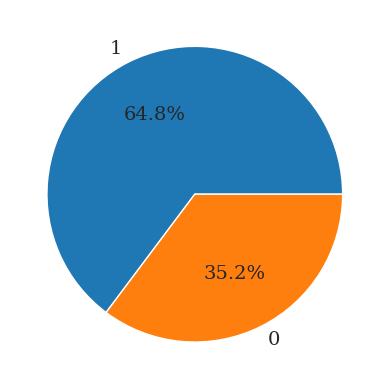

In [16]:
titanicdf['Sex'].value_counts().plot.pie(autopct='%1.1f%%')

Text(0.5, 0, 'Age')

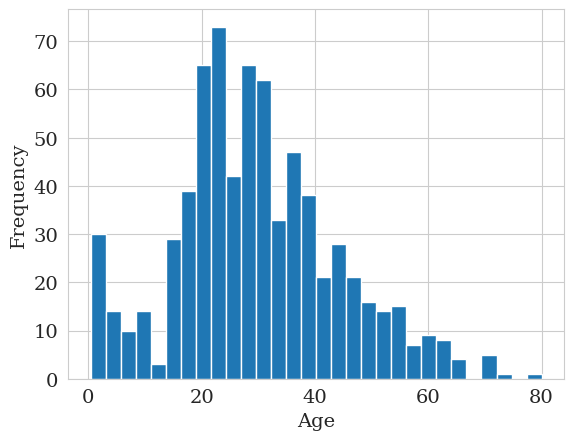

In [17]:
ax = titanicdf.Age.plot.hist(bins=30)
ax.set_xlabel("Age")

<Axes: xlabel='SibSp'>

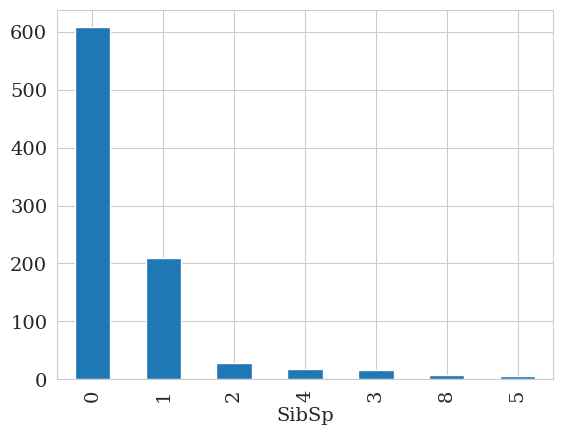

In [18]:
titanicdf.SibSp.value_counts().plot.bar()

<Axes: ylabel='Parch'>

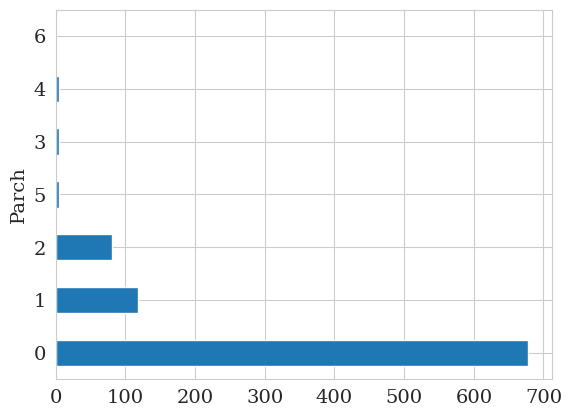

In [ ]:
titanicdf.Parch.value_counts().plot.barh()

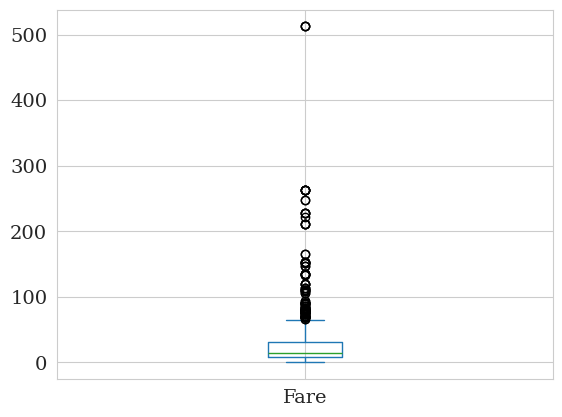

In [ ]:
ax = titanicdf.Fare.plot.box() # preço da passagem.

In [21]:
titanicdf.Cabin.values.unique() # varios tipos de valores distintos.

<StringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [22]:
# irei processar, pegando as primeiras letras
titanicdf['Cabin'] = titanicdf['Cabin'].str[0]

In [23]:
titanicdf.Cabin.value_counts()

Cabin
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64

In [24]:
titanicdf.Cabin.isna().value_counts()

Cabin
True     687
False    204
Name: count, dtype: int64

In [25]:
titanicdf['Cabin'] = titanicdf.Cabin.fillna('Unknown') # add uma flag para quando nao houver cabine

In [26]:
titanicdf.Cabin.value_counts()

Cabin
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

In [27]:
titanicdf['Cabin'] = pd.Categorical(titanicdf['Cabin']).codes

In [28]:
titanicdf.Cabin.value_counts()

Cabin
8    687
2     59
1     47
3     33
4     32
0     15
5     13
6      4
7      1
Name: count, dtype: int64

<Axes: xlabel='Embarked'>

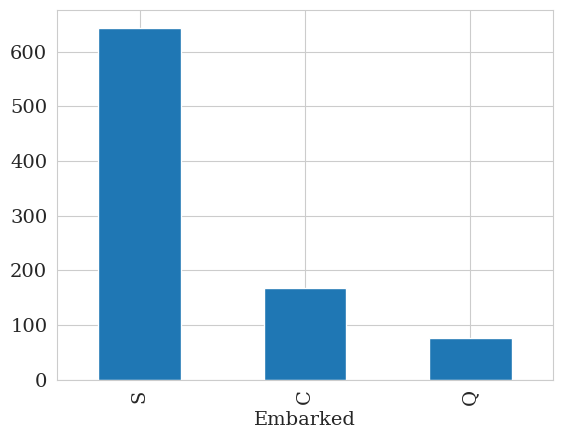

In [29]:
# é mais util aplicar one hot encoding
titanicdf.Embarked.value_counts().plot.bar()

In [30]:
dummies = pd.get_dummies(titanicdf.Embarked, dtype=int)
dummies

,C,Q,S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1
...,...,...,...
886,0,0,1
887,0,0,1
888,0,0,1
889,1,0,0


In [31]:
titanicdf = pd.concat([titanicdf, dummies], axis=1)

In [32]:
titanicdf = titanicdf.drop(columns=['Embarked'])
titanicdf

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,C,Q,S
0,0,3,1,22.0,1,0,7.2500,8,0,0,1
1,1,1,0,38.0,1,0,71.2833,2,1,0,0
2,1,3,0,26.0,0,0,7.9250,8,0,0,1
3,1,1,0,35.0,1,0,53.1000,2,0,0,1
4,0,3,1,35.0,0,0,8.0500,8,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,8,0,0,1
887,1,1,0,19.0,0,0,30.0000,1,0,0,1
888,0,3,0,NaN,1,2,23.4500,8,0,0,1
889,1,1,1,26.0,0,0,30.0000,2,1,0,0


In [33]:
titanicdf.dtypes

Survived      int64
Pclass        int64
Sex            int8
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin          int8
C             int64
Q             int64
S             int64
dtype: object

### Trabalhando os dados ausentes

In [34]:
titanicdf.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin         0
C             0
Q             0
S             0
dtype: int64

<Axes: ylabel='Age'>

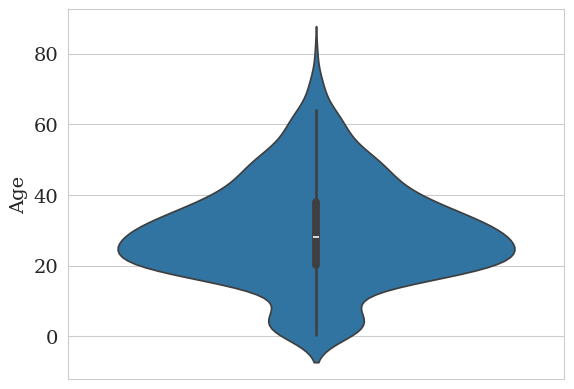

In [35]:
sns.violinplot(data=titanicdf, y='Age')

In [36]:
# imputando a media nos valores ausentes de idade
titanicdf['Age'] = titanicdf['Age'].fillna(titanicdf['Age'].mean())

In [37]:
titanicdf['Age'].isna().sum()

np.int64(0)

In [38]:
titanicdf.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Cabin       0
C           0
Q           0
S           0
dtype: int64

### Visualizando correlações dos dados

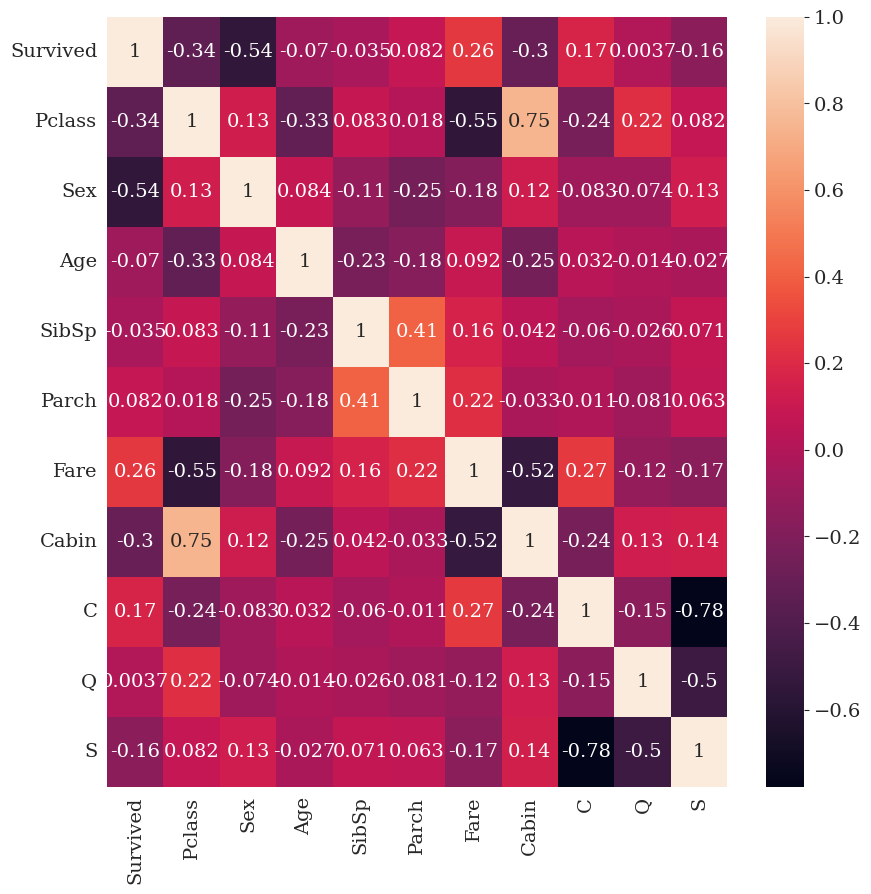

In [39]:
plt.figure(figsize=(10, 10))
axs = sns.heatmap(titanicdf.corr(), annot=True)

* Pela análise do gráfico de correlação, as correlações que existem com *survived* são (considerando o `threshold > 0.3`):
> Pclass

> Sex

#### Análise do `Pclass`

<Axes: xlabel='Pclass', ylabel='count'>

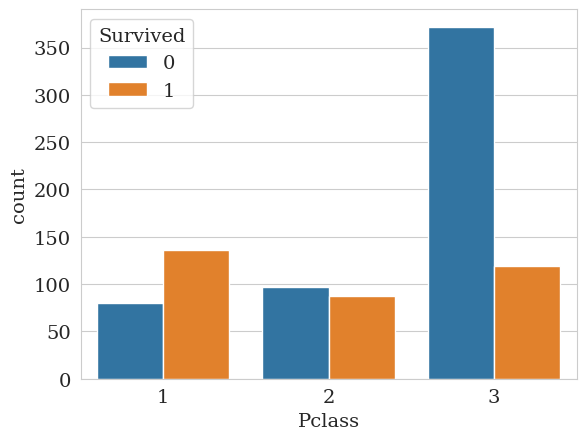

In [40]:
sns.countplot(data=titanicdf, x='Pclass', hue='Survived')

* Gráfico acima nos dá uma noção inicial: dentro da 3ª classe, uma grande quantidade de pessoas nao sobreviveu comparado as que sobreviveram. Confirmando calculandoa as proporções:

In [41]:
survived_rate = titanicdf.groupby(by='Pclass').sum()['Survived'] / titanicdf['Pclass'].value_counts()
survived_rate.name = "Survived Rate"
survived_rate

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived Rate, dtype: float64

* taxa de sobrevivência para cada uma das classes dos ingressos. Indica que pessoas nas melhores classes tiveram maior chance de sobrevivência, provavelmente pelas cabines estarem mais proximas de locais para evacuação

#### Análise do `Sex`

<Axes: xlabel='Sex', ylabel='count'>

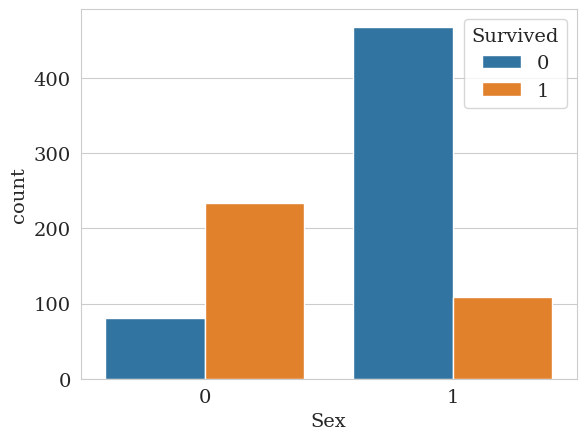

In [42]:
# 1 é masculino
sns.countplot(data=titanicdf, x='Sex', hue='Survived')

In [43]:
survived_rate_per_sex = titanicdf.groupby(by='Sex').sum()['Survived'] / titanicdf['Sex'].value_counts()
survived_rate_per_sex

Sex
0    0.742038
1    0.188908
dtype: float64

* taxa de sobrevivência entre as mulheres foi maior do que entre os homens, provavelmente para tentar proteger primeiro as mulheres e crianças

## Aplicando um modelo preditivo

* baseado na análise anterior, foi possivel perceber que quanto melhor a classe da pessoa, maior a chance de sobrevivência, e também que o sexo da pessoa importava, pois mulheres tiveram maior taxa de sobrevivência entre elas do que entre os homens.

### Preparando os dados

In [44]:
y = titanicdf.Survived
X = titanicdf.drop(columns=['Survived'])

In [45]:
SEED=42
np.random.seed(SEED)

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X.to_numpy(), y.to_numpy(), test_size=0.2, shuffle=True)

In [48]:
X_train, y_train

(array([[ 1. ,  1. , 45.5, ...,  0. ,  0. ,  1. ],
        [ 2. ,  1. , 23. , ...,  0. ,  0. ,  1. ],
        [ 3. ,  1. , 32. , ...,  0. ,  0. ,  1. ],
        ...,
        [ 3. ,  1. , 41. , ...,  0. ,  0. ,  1. ],
        [ 1. ,  0. , 14. , ...,  0. ,  0. ,  1. ],
        [ 1. ,  1. , 21. , ...,  0. ,  0. ,  1. ]], shape=(712, 10)),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
        1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
        1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
        1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,
        0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,

### Importando e treinando o modelo

#### Logistic Regression

In [49]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=SEED)

In [50]:
model.fit(X_train, y_train)

/home/ricardoervilha/anaconda3/envs/aprendizado_de_maquina/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [51]:
y_pred = model.predict(X_test)

In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



<Axes: >

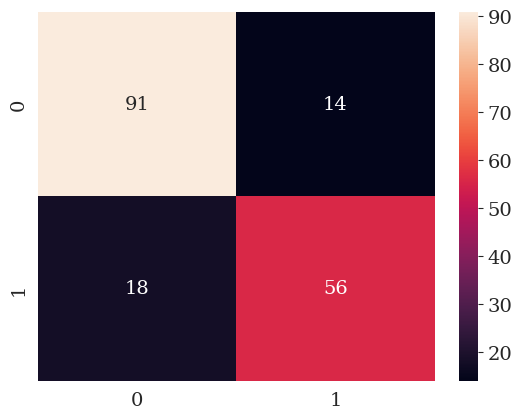

In [53]:
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

#### Random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier

rfmodel = RandomForestClassifier(random_state=SEED)

In [55]:
rfmodel.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [56]:
y_pred = rfmodel.predict(X_test)

In [57]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



<Axes: >

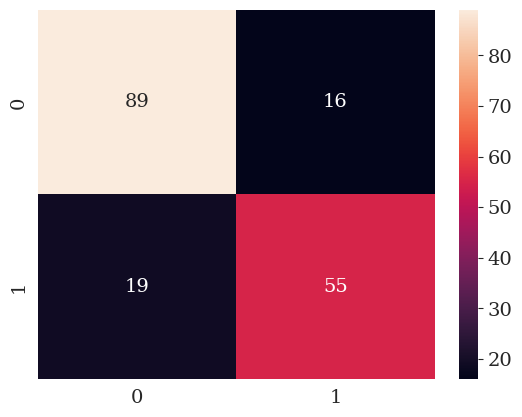

In [58]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

Text(0, 0.5, 'Features')

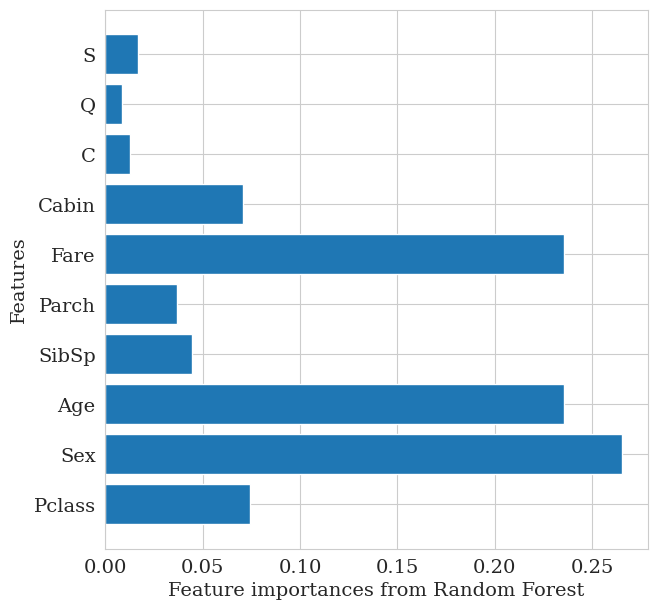

In [59]:
plt.figure(figsize=(7,7))
plt.barh(X.columns, rfmodel.feature_importances_)
plt.xlabel("Feature importances from Random Forest")
plt.ylabel("Features")

* percebe-se a partir do modelo de floresta aleatória, que ele identificou o sexo como uma feature muito importante, além do `Fare` e `Age`, coisas que não haviam sido percebidas na análise anterior.

## Analisando melhor a idade

<Axes: ylabel='Frequency'>

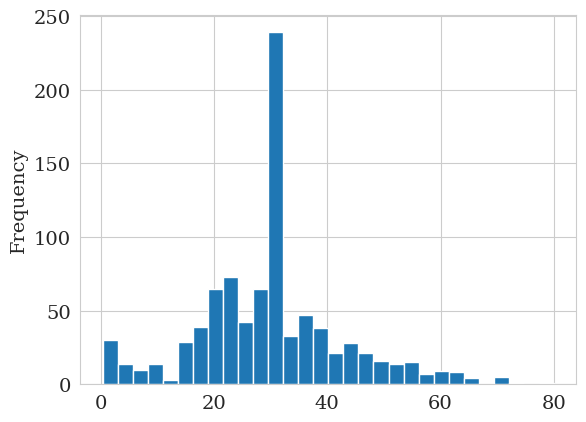

In [62]:
titanicdf['Age'].plot.hist(bins=30)

Distribuição da idade para a classe 1.


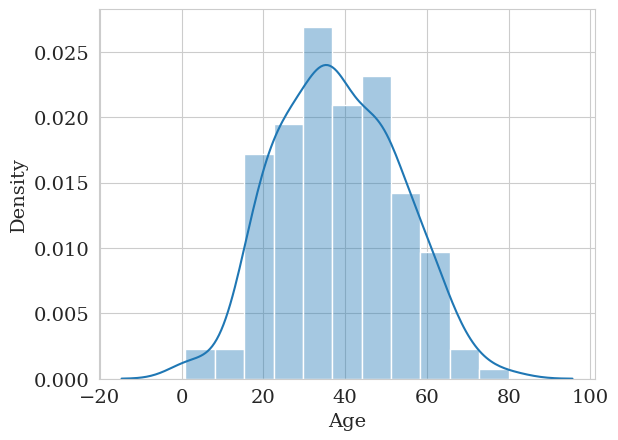

Distribuição da idade para a classe 2.


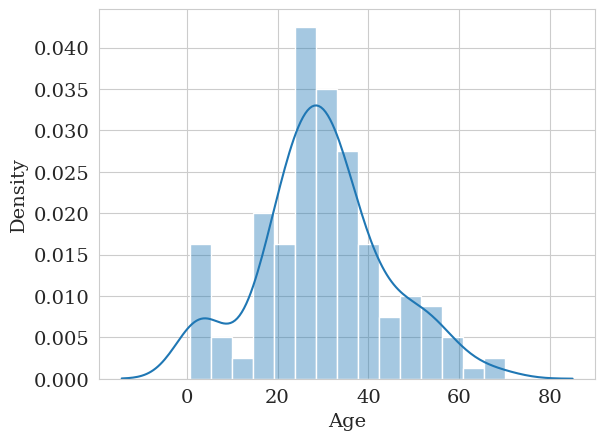

Distribuição da idade para a classe 3.


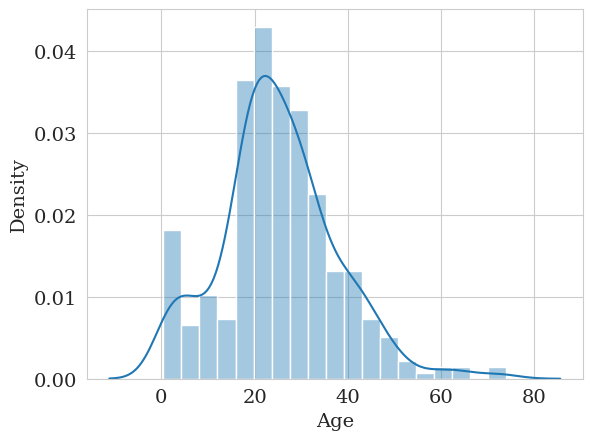

In [ ]:
gpb = titanicdf[['Age', 'Pclass']].groupby('Pclass')

for pclass, df in gpb:
    print(f"Distribuição da idade para a classe {pclass}.")
    df = df[df['Age'] != titanicdf['Age'].mean()] # <- no pré-processamento imputei a média e agora estou removendo o viés.
    sns.histplot(data=df , x='Age', stat="density", alpha=0.4)
    sns.kdeplot(data=df, x='Age')
    plt.show()

* média de idade (visualizando os graficos):
    * classe 1: volta dos 40 anos
    * classe 2: volta dos 25-30 anos
    * classe 3: volta dos 20 anos

* ou seja: classes mais altas eram ocupadas por pessoas mais velhas.